# Notebook 3 - train / validation / test split

Reads `02_labeled.parquet` and writes `03_train.parquet`, `03_val.parquet`, `03_test.parquet`.

The split comes before the EDA because leakage is not only a coding mistake. Looking at all the
data and then deciding which features to use or how to treat an anomaly builds those decisions on
the test set, and the gap only shows up in production. So: split first, and the test set stays
closed until notebook 6.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_auc_score

ARTIFACTS = Path("..") / "artifacts"

df = pd.read_parquet(ARTIFACTS / "02_labeled.parquet")
print(f"Read: {len(df):,} rows x {df.shape[1]} columns")
print(f"Time range: {df['order_purchase_timestamp'].min():%Y-%m-%d}"
      f"  ->  {df['order_purchase_timestamp'].max():%Y-%m-%d}")
print(f"Overall late rate: {100*df['is_late'].mean():.2f}%")

Read: 96,470 rows x 41 columns
Time range: 2016-09-15  ->  2018-08-29
Overall late rate: 6.77%


## 1. Random or chronological?

The task asks for the choice and the reason. Two arguments, examined separately.

The popular one is that a random split leaks customers: the same customer appears on both sides
and the model has seen their behaviour. Whether that applies here is a measurable question.

In [2]:
per_customer = df["customer_unique_id"].value_counts()

print(f"Distinct customers        : {len(per_customer):,}")
print(f"Ordered more than once    : {(per_customer > 1).sum():,}"
      f"  ({100*(per_customer > 1).sum()/len(per_customer):.2f}%)")
print(f"Ordered exactly once      : {(per_customer == 1).sum():,}"
      f"  ({100*(per_customer == 1).sum()/len(per_customer):.2f}%)")

Distinct customers        : 93,350
Ordered more than once    : 2,801  (3.00%)
Ordered exactly once      : 90,549  (97.00%)


97% of customers ordered once, so there is almost no customer history to leak and this argument
carries little weight here. The real problem is elsewhere.

Notebook 2 showed the late rate swinging month to month. How much signal does the date alone
carry? Using the late rate of an order's own month as if it were a prediction gives a direct
answer - no model, just a `groupby`.

In [3]:
month = df["order_purchase_timestamp"].dt.to_period("M")

# for every order: the late rate of the month it fell in
month_rate = df.groupby(month)["is_late"].transform("mean")

auc_month = roc_auc_score(df["is_late"], month_rate)
print(f"ROC-AUC using the month's late rate alone as the prediction: {auc_month:.3f}")

ROC-AUC using the month's late rate alone as the prediction: 0.698


0.698 from the month alone, against 0.679 for the Task 1 baseline with every purchase-time
feature it had.

A random split puts March 2018 (19% late) and June 2018 (1% late) on both sides, so the model can
memorise "March 2018 orders are late" and collect the score. In production it predicts for a month
that has not happened yet, where that information does not exist.

So the split is chronological: train on the past, test on the future. The task asks for the label
ratio to be preserved across splits *if the split is random*; this one is not, and the differing
base rates are the phenomenon itself.

## 2. Choosing the boundaries

Train has to be large enough to learn from and test large enough to measure, and validation should
sit close in time to test so that it indicates anything about it. Three options compared before
choosing.

In [4]:
candidates = {
    "A: val from 2018-01": ("2018-01-01", "2018-04-01"),
    "B: val from 2018-03": ("2018-03-01", "2018-05-01"),
    "C: val from 2018-04": ("2018-04-01", "2018-06-01"),
}

rows = []
for name, (val_start, test_start) in candidates.items():
    val_start, test_start = pd.Timestamp(val_start), pd.Timestamp(test_start)
    ts = df["order_purchase_timestamp"]
    parts = {"train": df[ts < val_start],
             "val":   df[(ts >= val_start) & (ts < test_start)],
             "test":  df[ts >= test_start]}
    row = {"option": name}
    for p, s in parts.items():
        row[f"{p} %"] = round(100*len(s)/len(df), 1)
        row[f"{p} late%"] = round(100*s["is_late"].mean(), 2)
    rows.append(row)

pd.DataFrame(rows).set_index("option")

,train %,train late%,val %,val late%,test %,test late%
option,,,,,,
A: val from 2018-01,45.3,5.62,21.4,12.88,33.3,4.42
B: val from 2018-03,59.4,6.60,14.3,11.84,26.3,4.40
C: val from 2018-04,66.7,7.95,14.0,5.53,19.3,3.61


Option C: train up to 2018-03-31, validation April-May 2018, test from 2018-06-01.

Under option A the validation late rate is roughly double the test one, which makes validation a
misleading indicator. Under C the two are neighbours and come close.

February and March 2018 (14% and 19% late) stay in training - shipping crises happen, and the model
should have seen their conditions.

In [5]:
VAL_START  = pd.Timestamp("2018-04-01")
TEST_START = pd.Timestamp("2018-06-01")

ts = df["order_purchase_timestamp"]
df["split"] = np.select(
    [ts < VAL_START, ts < TEST_START],
    ["train", "val"],
    default="test",
)

df["split"].value_counts().reindex(["train", "val", "test"]).to_frame("orders")

,orders
split,
train,64320
val,13547
test,18603


## 3. Inspecting the splits

In [6]:
summary = (df.groupby("split")
             .agg(orders=("order_id", "size"),
                  first_order=("order_purchase_timestamp", "min"),
                  last_order=("order_purchase_timestamp", "max"),
                  late_rate=("is_late", "mean"),
                  late_orders=("is_late", "sum"))
             .reindex(["train", "val", "test"]))

summary["share %"]  = (100*summary["orders"]/len(df)).round(1)
summary["late %"]   = (100*summary["late_rate"]).round(2)
summary = summary.drop(columns="late_rate")
summary[["orders", "share %", "first_order", "last_order", "late_orders", "late %"]]

,orders,share %,first_order,last_order,late_orders,late %
split,,,,,,
train,64320,66.7,2016-09-15 12:16:38,2018-03-31 23:54:10,5113,7.95
val,13547,14.0,2018-04-01 00:11:32,2018-05-31 23:51:24,749,5.53
test,18603,19.3,2018-06-01 00:39:55,2018-08-29 15:00:37,672,3.61


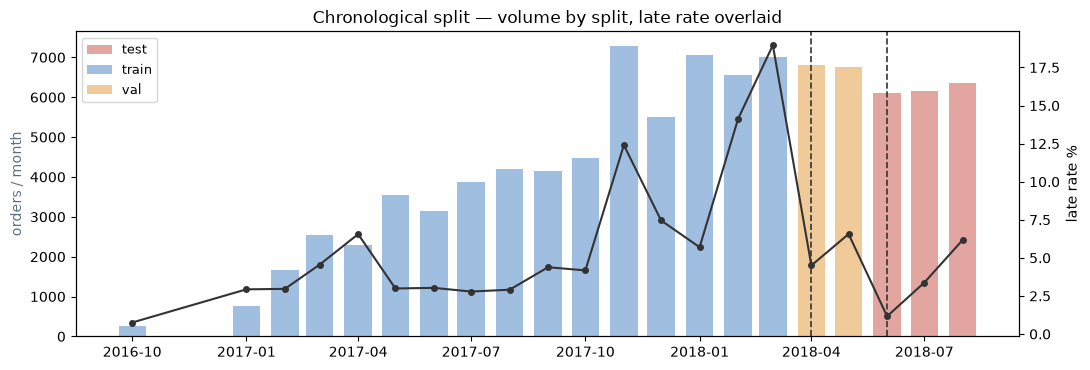

In [7]:
monthly = (df.assign(month=df["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp())
             .groupby(["month", "split"])
             .agg(orders=("order_id", "size"), late=("is_late", "mean"))
             .reset_index())
monthly = monthly[monthly["orders"] >= 100]

colors = {"train": "#2c6fbb", "val": "#e08a1e", "test": "#c0392b"}

fig, ax = plt.subplots(figsize=(11, 3.8))
for part, g in monthly.groupby("split"):
    ax.bar(g["month"], g["orders"], width=22, color=colors[part], alpha=.45, label=part)
ax.set_ylabel("orders / month", color="#5b7086")

ax2 = ax.twinx()
ax2.plot(monthly["month"], 100*monthly["late"], color="#333", marker="o",
         markersize=4, linewidth=1.5)
ax2.set_ylabel("late rate %")
for cut in (VAL_START, TEST_START):
    ax.axvline(cut, color="#333", linestyle="--", linewidth=1.2)

ax.set_title("Chronological split — volume by split, late rate overlaid")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## 4. Orders that cross the boundary

The split is by purchase date, but the label is only known on the delivery day. An order bought on
25 March and delivered on 10 April sits in train even though its label was not known when the
validation period started.

In [8]:
train_part = df[df["split"] == "train"]
crossing = (train_part["order_delivered_customer_date"] >= VAL_START).sum()

print(f"Orders in train delivered on/after the start of validation: {crossing:,}"
      f"  ({100*crossing/len(train_part):.2f}% of train)")
print(f"Median delivery duration: "
      f"{(df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days.median():.0f} days")

Orders in train delivered on/after the start of validation: 3,852  (5.99% of train)
Median delivery duration: 10 days


Documented, not removed. The effect is ~6% of train and second order: the model never sees a
validation label, it trains on orders whose outcome landed about ten days past the cut-off.

The strict remedy is an embargo - dropping every train order delivered after the cut-off - at a
cost of 6% of the training data. It stays an open option and is stated when results are reported.

## 5. Checks

In [9]:
train = df[df["split"] == "train"].drop(columns="split").copy()
val   = df[df["split"] == "val"].drop(columns="split").copy()
test  = df[df["split"] == "test"].drop(columns="split").copy()

# 1) no row was lost and none was duplicated
assert len(train) + len(val) + len(test) == len(df), "the parts do not sum to the original"

# 2) no order appears in more than one split
ids = [set(p["order_id"]) for p in (train, val, test)]
assert not (ids[0] & ids[1]) and not (ids[1] & ids[2]) and not (ids[0] & ids[2]), "order_id overlap"

# 3) the chronological order holds - no overlap in dates
assert train["order_purchase_timestamp"].max() < val["order_purchase_timestamp"].min()
assert val["order_purchase_timestamp"].max()   < test["order_purchase_timestamp"].min()

print(f"OK  {len(train):,} + {len(val):,} + {len(test):,} = {len(df):,}")
print("OK  no order_id overlap between the splits")
print("OK  no time overlap - every split precedes the next")

OK  64,320 + 13,547 + 18,603 = 96,470
OK  no order_id overlap between the splits
OK  no time overlap - every split precedes the next


In [10]:
# repeat customers that cross the boundaries: measured for information, not for removal
cust = {n: set(p["customer_unique_id"]) for n, p in
        [("train", train), ("val", val), ("test", test)]}

print(f"customers in both train and val  : {len(cust['train'] & cust['val']):,}")
print(f"customers in both train and test : {len(cust['train'] & cust['test']):,}")
print(f"customers in both val and test   : {len(cust['val'] & cust['test']):,}")
print(f"\nout of {df['customer_unique_id'].nunique():,} customers - a negligible effect, "
      "and the model carries no customer-level feature in the first place.")

customers in both train and val  : 304
customers in both train and test : 314
customers in both val and test   : 120

out of 93,350 customers - a negligible effect, and the model carries no customer-level feature in the first place.


## 6. Saving

In [11]:
for name, part in [("train", train), ("val", val), ("test", test)]:
    out = ARTIFACTS / f"03_{name}.parquet"
    part.to_parquet(out, index=False)
    print(f"{out.name:<18} {len(part):>7,} rows   "
          f"{100*part['is_late'].mean():5.2f}% late   "
          f"{out.stat().st_size/1024**2:5.1f} MB")

03_train.parquet    64,320 rows    7.95% late    11.9 MB
03_val.parquet      13,547 rows    5.53% late     2.7 MB
03_test.parquet     18,603 rows    3.61% late     3.6 MB


---

**Why this split.** The late rate here runs from 1% to 19% by month, and the month's own rate scores
ROC-AUC 0.698 on its own - more than every purchase-time feature combined (0.679). A random split
would hand the model that for free, and production has no such information. The usual customer-leak
argument does not apply: 97% of customers ordered once.

| | |
|---|---|
| Type | chronological, no shuffling, no stratification |
| Boundaries | train to 2018-03-31, val Apr-May 2018, test from 2018-06-01 |
| Shares | 67% / 14% / 19% |
| Late rates | 7.95% / 5.53% / 3.61% |
| Known limitation | ~6% of train delivered after the cut-off, no embargo |

Because the base rates differ, a threshold tuned on validation will not transfer to test - notebook
6 uses ranking metrics and recall at a fixed alert budget instead.

Notebook 4 runs on `03_train.parquet` only.